# Basics of Transformers

Reference paper: *"Attention Is All You Need"* (Vaswani et al., 2017)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # for reproducible results
print("Setup complete!")

Setup complete!


---
## 1. Why Transformers? The Problem with RNNs

Before 2017, sequence models (like translators) used **Recurrent Neural Networks (RNNs)**. RNNs read a sentence **one word at a time**, left to right:

```
"The" → "cat" → "sat" → "on" → "the" → "mat"
```

**Problems with RNNs:**
- **Slow:** words must be processed sequentially — you cannot parallelize.
- **Forgetful:** by the time the model reaches word 100, it has mostly forgotten word 1 (the *long-range dependency* problem).

**The Transformer's big idea:** process **all words at the same time**, and let every word directly "look at" every other word using a mechanism called **attention**.

| | RNN | Transformer |
|---|---|---|
| Processing | Sequential (one word at a time) | Parallel (all words at once) |
| Long-range memory | Weak | Strong (direct connections) |
| Training speed | Slow | Fast on GPUs |


---
## 2. Tokenization: Text → Numbers

Neural networks work with numbers, not words. **Tokenization** splits text into pieces (*tokens*) and maps each to an integer ID using a **vocabulary**.

Let's build a tiny word-level tokenizer:

In [2]:
# A tiny corpus and vocabulary
sentence = "the cat sat on the mat"
words = sentence.split()

# Build vocabulary: unique words -> integer IDs
vocab = {word: idx for idx, word in enumerate(sorted(set(words)))}
print("Vocabulary:", vocab)

# Tokenize: convert the sentence into token IDs
token_ids = [vocab[w] for w in words]
print("Sentence :", words)
print("Token IDs:", token_ids)

Vocabulary: {'cat': 0, 'mat': 1, 'on': 2, 'sat': 3, 'the': 4}
Sentence : ['the', 'cat', 'sat', 'on', 'the', 'mat']
Token IDs: [4, 0, 3, 2, 4, 1]


>**Note:** Real models (GPT, Claude, BERT) use *subword* tokenizers (BPE, WordPiece) that can handle any word by splitting rare words into pieces, e.g. `"transformers"` → `["transform", "ers"]`. The idea is the same: **text becomes a list of integers**.

---
## 3. Embeddings: Giving Tokens Meaning

A token ID like `3` carries no meaning by itself. An **embedding layer** maps each token ID to a **vector** of real numbers (e.g., 512 dimensions in the original paper). These vectors are *learned* during training so that similar words end up with similar vectors.

Here we'll use a small embedding dimension `d_model = 8` so we can see everything:

In [3]:
vocab_size = len(vocab)
d_model = 8  # embedding dimension (512 in the original paper)

# Embedding matrix: one row (vector) per word in the vocabulary
# In a real model these numbers are LEARNED. Here they are random.
embedding_matrix = np.random.randn(vocab_size, d_model) * 0.5

# Look up the embedding for each token in our sentence
X = embedding_matrix[token_ids]   # shape: (sequence_length, d_model)
print("Shape of embedded sentence:", X.shape)  # (6 words, 8 dims)
print("\nEmbedding of 'cat':\n", np.round(X[1], 3))

Shape of embedded sentence: (6, 8)

Embedding of 'cat':
 [ 0.248 -0.069  0.324  0.762 -0.117 -0.117  0.79   0.384]


---
## 4. Positional Encoding: Where Is Each Word?

Since the Transformer looks at all words **simultaneously**, it has no idea about word *order* — "dog bites man" and "man bites dog" would look identical!

**Solution:** add a **positional encoding** vector to each embedding. The original paper uses sine and cosine waves of different frequencies:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \qquad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

where `pos` is the word's position and `i` is the dimension index.

In [4]:
def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    positions = np.arange(seq_len)[:, np.newaxis]          # (seq_len, 1)
    div_term = 10000 ** (np.arange(0, d_model, 2) / d_model)
    PE[:, 0::2] = np.sin(positions / div_term)  # even dimensions
    PE[:, 1::2] = np.cos(positions / div_term)  # odd dimensions
    return PE

PE = positional_encoding(seq_len=len(token_ids), d_model=d_model)

# Add position information to the word embeddings
X_with_pos = X + PE
print("Shape after adding positions:", X_with_pos.shape)

Shape after adding positions: (6, 8)


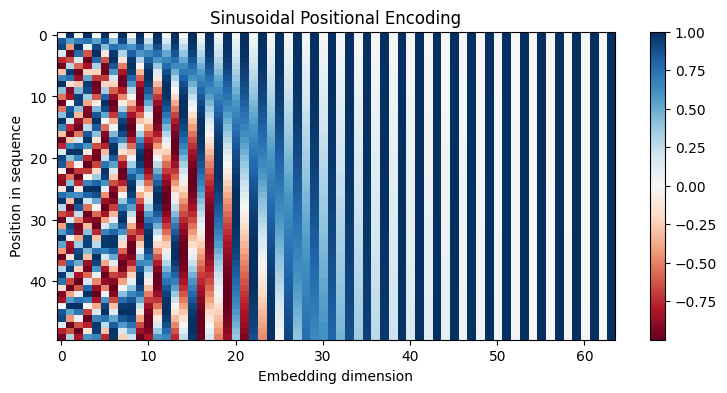

In [5]:
# Visualize positional encodings for a longer sequence
PE_big = positional_encoding(seq_len=50, d_model=64)

plt.figure(figsize=(9, 4))
plt.imshow(PE_big, cmap="RdBu", aspect="auto")
plt.xlabel("Embedding dimension")
plt.ylabel("Position in sequence")
plt.title("Sinusoidal Positional Encoding")
plt.colorbar()
plt.show()

# Notice: each row (position) has a unique "barcode" pattern!

---
## 5. Self-Attention: The Heart of the Transformer

**Intuition:** When reading the sentence *"The animal didn't cross the street because **it** was too tired"*, how do you know what **"it"** refers to? You *attend* to "animal". Self-attention lets every word gather information from the most relevant other words.

### Queries, Keys, and Values

Each word's vector is projected into three roles:

| Vector | Analogy | Meaning |
|---|---|---|
| **Query (Q)** | A search question | "What am I looking for?" |
| **Key (K)** | A label/tag | "What do I contain?" |
| **Value (V)** | The content | "What information do I give if selected?" |

### The Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Step by step:**
1. $QK^T$ — compare every query with every key → similarity **scores**
2. $\div \sqrt{d_k}$ — scale down so softmax doesn't saturate
3. **softmax** — turn scores into **attention weights** (probabilities summing to 1)
4. multiply by $V$ — take a **weighted average of the values**

Let's implement it from scratch:

In [6]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)  # numerical stability
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def self_attention(X, W_q, W_k, W_v):
    """X: (seq_len, d_model). Returns output and attention weights."""
    Q = X @ W_q          # queries
    K = X @ W_k          # keys
    V = X @ W_v          # values
    d_k = Q.shape[-1]

    scores  = Q @ K.T / np.sqrt(d_k)     # (seq_len, seq_len)
    weights = softmax(scores, axis=-1)   # each row sums to 1
    output  = weights @ V                # weighted average of values
    return output, weights

# Random (untrained) projection matrices
d_k = 8
W_q = np.random.randn(d_model, d_k) * 0.5
W_k = np.random.randn(d_model, d_k) * 0.5
W_v = np.random.randn(d_model, d_k) * 0.5

attn_out, attn_weights = self_attention(X_with_pos, W_q, W_k, W_v)
print("Attention output shape :", attn_out.shape)
print("Attention weights shape:", attn_weights.shape)
print("\nEach row sums to 1?  ->", np.allclose(attn_weights.sum(axis=1), 1))

Attention output shape : (6, 8)
Attention weights shape: (6, 6)

Each row sums to 1?  -> True


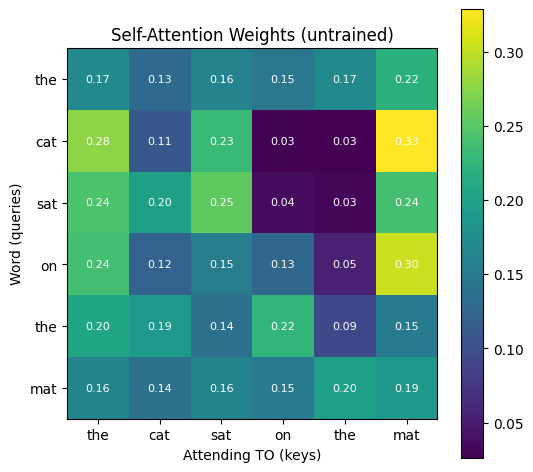

In [7]:
# Visualize the attention matrix: who is looking at whom?
plt.figure(figsize=(5.5, 5))
plt.imshow(attn_weights, cmap="viridis")
plt.xticks(range(len(words)), words)
plt.yticks(range(len(words)), words)
plt.xlabel("Attending TO (keys)")
plt.ylabel("Word (queries)")
plt.title("Self-Attention Weights (untrained)")
plt.colorbar()
for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f"{attn_weights[i, j]:.2f}",
                 ha="center", va="center", color="white", fontsize=8)
plt.tight_layout()
plt.show()

# NOTE: the weights look fairly uniform because our matrices are random.
# After TRAINING, meaningful patterns emerge (e.g., "it" attends to "animal").

---
## 6. Multi-Head Attention: Many Perspectives at Once

One attention operation captures **one kind** of relationship. But language has many: grammar, meaning, coreference...

**Multi-head attention** runs several attention operations (**heads**) *in parallel*, each with its own $W_q, W_k, W_v$ matrices, then concatenates the results:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W_O$$

Think of it as a **team of specialists** — one head might track subject–verb pairs, another might track adjectives and nouns.

In [8]:
def multi_head_attention(X, num_heads=2):
    d_model = X.shape[-1]
    d_head = d_model // num_heads   # split dimensions across heads
    head_outputs = []

    for h in range(num_heads):
        W_q = np.random.randn(d_model, d_head) * 0.5
        W_k = np.random.randn(d_model, d_head) * 0.5
        W_v = np.random.randn(d_model, d_head) * 0.5
        out, _ = self_attention(X, W_q, W_k, W_v)
        head_outputs.append(out)

    concat = np.concatenate(head_outputs, axis=-1)     # (seq_len, d_model)
    W_O = np.random.randn(d_model, d_model) * 0.5      # output projection
    return concat @ W_O

mha_out = multi_head_attention(X_with_pos, num_heads=2)
print("Multi-head attention output shape:", mha_out.shape)

Multi-head attention output shape: (6, 8)


---
## 7. The Full Transformer Block

A Transformer is a **stack** of identical blocks. Each block contains:

```
Input
  │
  ├──► Multi-Head Attention ──► Add (residual) & LayerNorm
  │                                   │
  ├───────────────────────────────────┤
  │                                   ▼
  ├──► Feed-Forward Network  ──► Add (residual) & LayerNorm
  │                                   │
  └───────────────────────────────────┘
                                      ▼
                                   Output
```

- **Residual connection (Add):** output = layer(x) **+ x**. Helps gradients flow in deep networks.
- **Layer Normalization:** keeps values in a stable range so training doesn't blow up.
- **Feed-Forward Network (FFN):** two linear layers with ReLU, applied to each position independently. This is where the model "thinks" about each word after gathering context.

In [11]:
def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std  = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

def feed_forward(x, d_ff=32):
    d_model = x.shape[-1]
    W1 = np.random.randn(d_model, d_ff) * 0.5
    W2 = np.random.randn(d_ff, d_model) * 0.5
    return np.maximum(0, x @ W1) @ W2   # ReLU in the middle

def transformer_block(x):
    # Sub-layer 1: attention + residual + norm
    attn = multi_head_attention(x, num_heads=2)
    x = layer_norm(x + attn)
    # Sub-layer 2: feed-forward + residual + norm
    ffn = feed_forward(x)
    x = layer_norm(x + ffn)
    return x

block_out = transformer_block(X_with_pos)
print("Transformer block output shape:", block_out.shape)
print("\nCompleted Transformer block from scratch!")

Transformer block output shape: (6, 8)

Completed Transformer block from scratch!


---
## 8. Encoder vs. Decoder — The Model Families

The original Transformer has an **encoder** (reads input) and a **decoder** (generates output). Modern models pick one:

| Family | Architecture | Attention style | Example models | Typical use |
|---|---|---|---|---|
| **Encoder-only** | Just encoder blocks | Bidirectional (sees whole sentence) | BERT | Classification, search |
| **Decoder-only** | Just decoder blocks | **Causal** (each word only sees the *past*) | GPT, Claude, LLaMA | Text generation, chatbots |
| **Encoder–Decoder** | Both | Mixed | T5, original Transformer | Translation, summarization |

**Causal masking** in decoders: when predicting the next word, the model is prevented from "cheating" by looking at future words. This is done by setting future attention scores to $-\infty$ before the softmax:

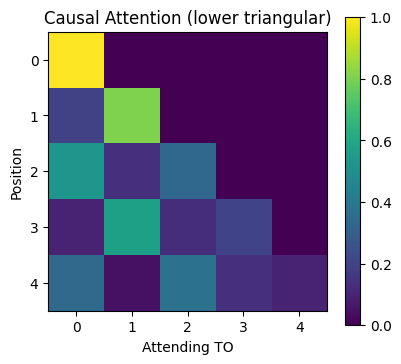

In [12]:
# Causal mask demo
seq_len = 5
mask = np.triu(np.ones((seq_len, seq_len)), k=1)  # 1s above the diagonal

scores = np.random.randn(seq_len, seq_len)
masked_scores = np.where(mask == 1, -1e9, scores)   # block the future
causal_weights = softmax(masked_scores, axis=-1)

plt.figure(figsize=(4.5, 4))
plt.imshow(causal_weights, cmap="viridis")
plt.title("Causal Attention (lower triangular)")
plt.xlabel("Attending TO")
plt.ylabel("Position")
plt.colorbar()
plt.show()
# Each position can only attend to itself and earlier positions!

---
## 9. (Optional) A Tiny Transformer in PyTorch

NumPy is great for learning, but real models use frameworks like **PyTorch**. Here is the same architecture in a few lines using built-in modules.

> Requires PyTorch: `pip install torch`

In [13]:
try:
    import torch
    import torch.nn as nn

    class TinyTransformer(nn.Module):
        def __init__(self, vocab_size, d_model=32, nhead=4, num_layers=2):
            super().__init__()
            self.embed = nn.Embedding(vocab_size, d_model)
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=64, batch_first=True
            )
            self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.out = nn.Linear(d_model, vocab_size)  # predict next token

        def forward(self, x):
            x = self.embed(x)
            x = self.encoder(x)
            return self.out(x)

    model = TinyTransformer(vocab_size=len(vocab))
    tokens = torch.tensor([token_ids])          # batch of 1 sentence
    logits = model(tokens)
    print("Input shape :", tokens.shape)         # (1, 6)
    print("Output shape:", logits.shape)         # (1, 6, vocab_size)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters  : {n_params:,}")
    print("\n(GPT-3 has ~175,000,000,000 parameters — same ideas, much bigger!)")
except ImportError:
    print("PyTorch not installed — skip this cell or run: pip install torch")

Input shape : torch.Size([1, 6])
Output shape: torch.Size([1, 6, 5])
Parameters  : 17,413

(GPT-3 has ~175,000,000,000 parameters — same ideas, much bigger!)


---
## 10. Summary & Key Takeaways

| Concept | One-line summary |
|---|---|
| **Tokenization** | Split text into pieces and map them to integer IDs |
| **Embedding** | Turn each token ID into a learned vector of meaning |
| **Positional encoding** | Add "position barcodes" so the model knows word order |
| **Self-attention** | Every word gathers info from relevant words: softmax(QKᵀ/√d)·V |
| **Multi-head** | Several attention "specialists" run in parallel |
| **Residual + LayerNorm** | Keep deep networks stable and trainable |
| **Causal mask** | In generators (GPT-style), words can only see the past |
| **Stacking blocks** | Depth = repeated refinement of representations |

### Exercises for Students
1. **Easy:** Change `d_model` to 16 and re-run the notebook. Do the shapes still work out? Why must `d_model` be divisible by `num_heads`?
2. **Medium:** Modify `self_attention` to accept a causal mask (Section 8) and plot the resulting attention weights for our sentence.
3. **Medium:** Add a new sentence to the vocabulary and visualize its attention matrix.
4. **Challenge:** Implement multi-head attention with *shared* weight matrices created once (instead of new random ones per call), and stack 3 transformer blocks.

### Further Reading
- *Attention Is All You Need* — Vaswani et al., 2017 (the original paper)
- *The Illustrated Transformer* — Jay Alammar (excellent visual blog post)
- *The Annotated Transformer* — Harvard NLP (paper + code, line by line)